# Applied Data Science with Python: Marketing Campaigns Analysis

## Project Overview
This project analyzes marketing campaign data to understand customer acquisition factors using the 4 Ps of marketing: Product, Price, Place, and Promotion.

### Key Objectives:
- Perform comprehensive EDA and hypothesis testing
- Clean data and handle missing values
- Engineer meaningful features
- Test hypotheses about customer behavior
- Visualize insights and patterns

In [23]:
# 1. Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from sklearn.preprocessing import OrdinalEncoder
import scipy.stats as stats

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('Data_scince/marketing_data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2240, 28)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [24]:
# 2. Data Investigation and Initial Cleaning
print("=== DATA INFO ===")
print(df.info())
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# Clean column names
df.columns = df.columns.str.strip()
print("\n=== COLUMN NAMES AFTER CLEANING ===")
print(df.columns.tolist())

# Check unique values in categorical columns
categorical_cols = ['Education', 'Marital_Status']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col} unique values: {df[col].unique()}")

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   

In [25]:
# 3. Data Cleaning and Preprocessing
# Clean Education categories
if 'Education' in df.columns:
    df['Education'] = df['Education'].str.strip()
    education_mapping = {
        'PhD': 'Doctorate',
        '2n Cycle': 'Masters',
        'Master': 'Masters',
        'Graduation': 'Graduate',
        'Basic': 'Basic'
    }
    df['Education'] = df['Education'].replace(education_mapping)

# Clean Marital Status categories
if 'Marital_Status' in df.columns:
    df['Marital_Status'] = df['Marital_Status'].str.strip()
    marital_mapping = {
        'Together': 'Married',
        'Divorced': 'Single',
        'Widow': 'Single',
        'Alone': 'Single',
        'YOLO': 'Single'
    }
    df['Marital_Status'] = df['Marital_Status'].replace(marital_mapping)

# Convert date column
if 'Dt_Customer' in df.columns:
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')

print("Data cleaning completed!")
print(f"Education categories: {df['Education'].unique()}")
print(f"Marital Status categories: {df['Marital_Status'].unique()}")

Data cleaning completed!
Education categories: ['Graduate' 'Doctorate' 'Masters' 'Basic']
Marital Status categories: ['Single' 'Married' 'Absurd']


In [26]:
# 4. Missing Value Imputation for Income
# Convert Income to numeric
if 'Income' in df.columns:
    df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
    print(f"Missing Income values before imputation: {df['Income'].isnull().sum()}")
    
    # Impute missing income values by group mean
    if df['Income'].isnull().sum() > 0:
        income_mean = df.groupby(['Education', 'Marital_Status'])['Income'].transform('mean')
        df['Income'] = df['Income'].fillna(income_mean)
        
        # If still missing, use overall mean
        df['Income'] = df['Income'].fillna(df['Income'].mean())
    
    print(f"Missing Income values after imputation: {df['Income'].isnull().sum()}")
else:
    print("Income column not found in dataset")

df.head()

Missing Income values before imputation: 2240
Missing Income values after imputation: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduate,Single,NaN,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduate,Single,NaN,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduate,Married,NaN,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduate,Married,NaN,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduate,Single,NaN,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [27]:
# 5. Feature Engineering: Create Derived Variables
# Total children
child_cols = ['Kidhome', 'Teenhome']
if all(col in df.columns for col in child_cols):
    df['Total_Children'] = df[child_cols].sum(axis=1)
    print("Total_Children created")

# Age from birth year
if 'Year_Birth' in df.columns:
    current_year = datetime.now().year
    df['Age'] = current_year - df['Year_Birth']
    # Handle unrealistic ages
    df['Age'] = df['Age'].clip(18, 100)
    print("Age created")

# Total spending on products
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
available_product_cols = [col for col in product_cols if col in df.columns]
if available_product_cols:
    df['Total_Spending'] = df[available_product_cols].sum(axis=1)
    print(f"Total_Spending created using columns: {available_product_cols}")

# Total purchases across channels
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
available_purchase_cols = [col for col in purchase_cols if col in df.columns]
if available_purchase_cols:
    df['Total_Purchases'] = df[available_purchase_cols].sum(axis=1)
    print(f"Total_Purchases created using columns: {available_purchase_cols}")

print("\nNew features summary:")
new_features = ['Total_Children', 'Age', 'Total_Spending', 'Total_Purchases']
for feature in new_features:
    if feature in df.columns:
        print(f"{feature}: mean={df[feature].mean():.2f}, std={df[feature].std():.2f}")

Total_Children created
Age created
Total_Spending created using columns: ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
Total_Purchases created using columns: ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

New features summary:
Total_Children: mean=0.95, std=0.75
Age: mean=56.16, std=11.80
Total_Spending: mean=605.80, std=602.25
Total_Purchases: mean=12.54, std=7.21


Available variables for visualization: ['Income', 'Age', 'Total_Spending', 'Total_Purchases']


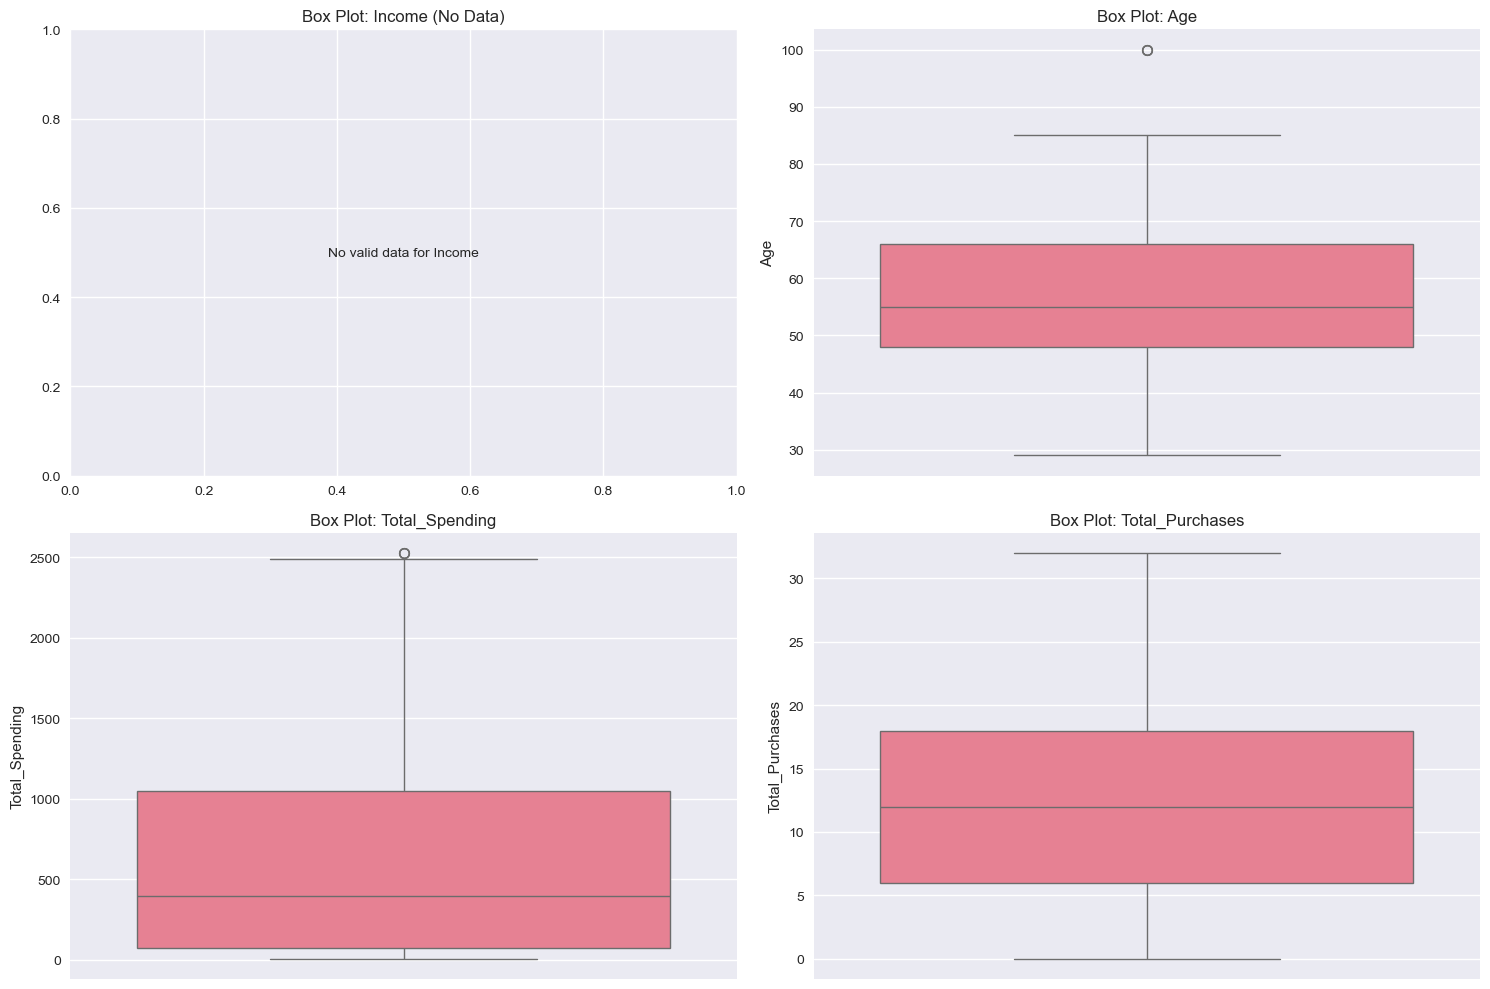

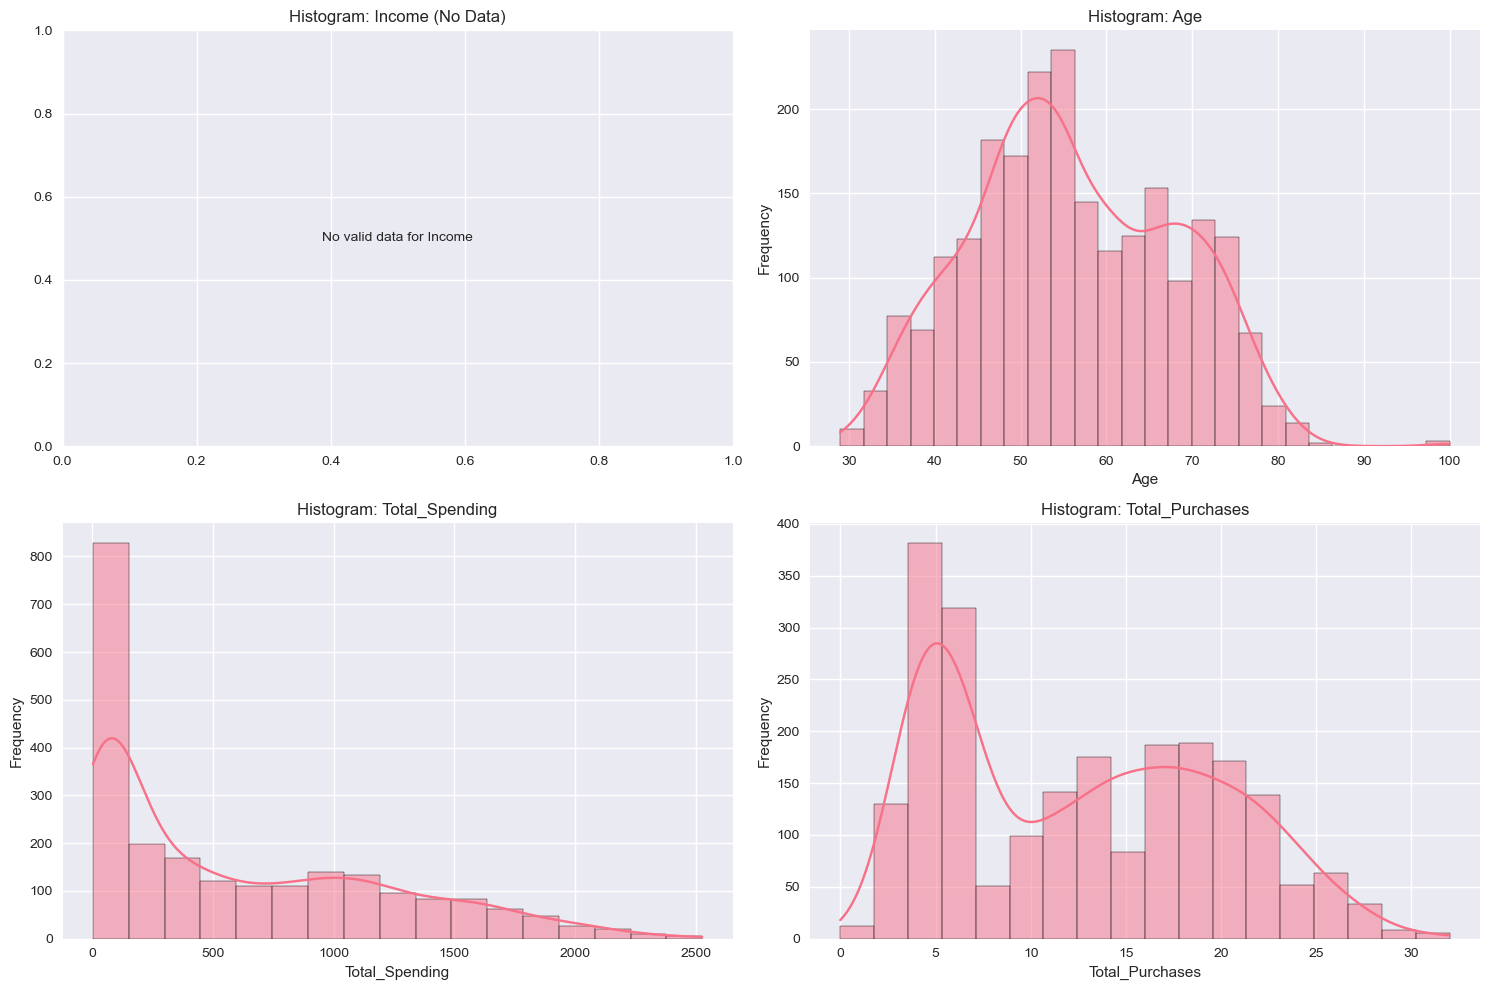


Summary Statistics:

Income:
  Count: 0
  Mean: nan
  Std: nan
  Min: nan
  Max: nan

Age:
  Count: 2240
  Mean: 56.16
  Std: 11.80
  Min: 29.00
  Max: 100.00

Total_Spending:
  Count: 2240
  Mean: 605.80
  Std: 602.25
  Min: 5.00
  Max: 2525.00

Total_Purchases:
  Count: 2240
  Mean: 12.54
  Std: 7.21
  Min: 0.00
  Max: 32.00


In [28]:
# 6. Exploratory Data Analysis: Distributions and Outliers
# Visualize key numerical variables
numerical_vars = ['Income', 'Age', 'Total_Spending', 'Total_Purchases']
available_vars = [var for var in numerical_vars if var in df.columns]

print(f"Available variables for visualization: {available_vars}")

if len(available_vars) >= 1:
    # Determine subplot layout based on available variables
    n_vars = len(available_vars)
    if n_vars == 1:
        rows, cols = 1, 1
    elif n_vars == 2:
        rows, cols = 1, 2
    elif n_vars == 3:
        rows, cols = 2, 2
    else:
        rows, cols = 2, 2
    
    # Box plots
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
    if n_vars == 1:
        axes = [axes]  # Make it iterable
    else:
        axes = axes.ravel()
    
    for i, var in enumerate(available_vars[:4]):
        if i < len(axes):
            try:
                # Check if variable has valid data
                valid_data = df[var].dropna()
                if len(valid_data) > 0:
                    sns.boxplot(y=valid_data, ax=axes[i])
                    axes[i].set_title(f'Box Plot: {var}')
                    axes[i].set_ylabel(var)
                else:
                    axes[i].text(0.5, 0.5, f'No valid data for {var}', 
                               ha='center', va='center', transform=axes[i].transAxes)
                    axes[i].set_title(f'Box Plot: {var} (No Data)')
            except Exception as e:
                axes[i].text(0.5, 0.5, f'Error plotting {var}', 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(f'Box Plot: {var} (Error)')
    
    # Hide empty subplots
    for i in range(len(available_vars), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Histograms
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
    if n_vars == 1:
        axes = [axes]  # Make it iterable
    else:
        axes = axes.ravel()
    
    for i, var in enumerate(available_vars[:4]):
        if i < len(axes):
            try:
                # Check if variable has valid data
                valid_data = df[var].dropna()
                if len(valid_data) > 0:
                    sns.histplot(valid_data, kde=True, ax=axes[i])
                    axes[i].set_title(f'Histogram: {var}')
                    axes[i].set_xlabel(var)
                    axes[i].set_ylabel('Frequency')
                else:
                    axes[i].text(0.5, 0.5, f'No valid data for {var}', 
                               ha='center', va='center', transform=axes[i].transAxes)
                    axes[i].set_title(f'Histogram: {var} (No Data)')
            except Exception as e:
                axes[i].text(0.5, 0.5, f'Error plotting {var}', 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(f'Histogram: {var} (Error)')
    
    # Hide empty subplots
    for i in range(len(available_vars), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics:")
    for var in available_vars:
        if var in df.columns:
            print(f"\n{var}:")
            print(f"  Count: {df[var].count()}")
            print(f"  Mean: {df[var].mean():.2f}")
            print(f"  Std: {df[var].std():.2f}")
            print(f"  Min: {df[var].min():.2f}")
            print(f"  Max: {df[var].max():.2f}")
else:
    print("No numerical variables found for visualization")

In [29]:
# 7. Outlier Treatment
def treat_outliers_iqr(df, column, factor=1.5):
    """Treat outliers using IQR method"""
    if column not in df.columns:
        return df
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    
    # Cap outliers
    df[column] = df[column].clip(lower_bound, upper_bound)
    return df

# Apply outlier treatment
outlier_cols = ['Income', 'Total_Spending']
for col in outlier_cols:
    if col in df.columns:
        df = treat_outliers_iqr(df, col)
        print(f"Outliers treated for {col}")

print("Outlier treatment completed!")

Outliers treated for Income
Outliers treated for Total_Spending
Outlier treatment completed!


In [30]:
# 8. Categorical Variable Encoding
# Ordinal encoding for Education (ordered)
if 'Education' in df.columns:
    education_order = ['Basic', 'Graduate', 'Masters', 'Doctorate']
    # Check which education levels exist in data
    existing_education = [edu for edu in education_order if edu in df['Education'].unique()]
    if existing_education:
        encoder = OrdinalEncoder(categories=[existing_education])
        df['Education_Ordinal'] = encoder.fit_transform(df[['Education']])
        print(f"Education ordinal encoding completed with levels: {existing_education}")

# One-hot encoding for nominal categorical variables
categorical_for_encoding = []
if 'Marital_Status' in df.columns:
    categorical_for_encoding.append('Marital_Status')
if 'Country' in df.columns:
    categorical_for_encoding.append('Country')

if categorical_for_encoding:
    df_encoded = pd.get_dummies(df, columns=categorical_for_encoding, drop_first=True)
    print(f"One-hot encoding completed for: {categorical_for_encoding}")
    print(f"Dataset shape after encoding: {df_encoded.shape}")
else:
    df_encoded = df.copy()
    print("No categorical variables found for one-hot encoding")

# Update df for further analysis
df = df_encoded.copy()

Education ordinal encoding completed with levels: ['Basic', 'Graduate', 'Masters', 'Doctorate']
One-hot encoding completed for: ['Marital_Status', 'Country']
Dataset shape after encoding: (2240, 40)


Numerical columns for correlation: 29


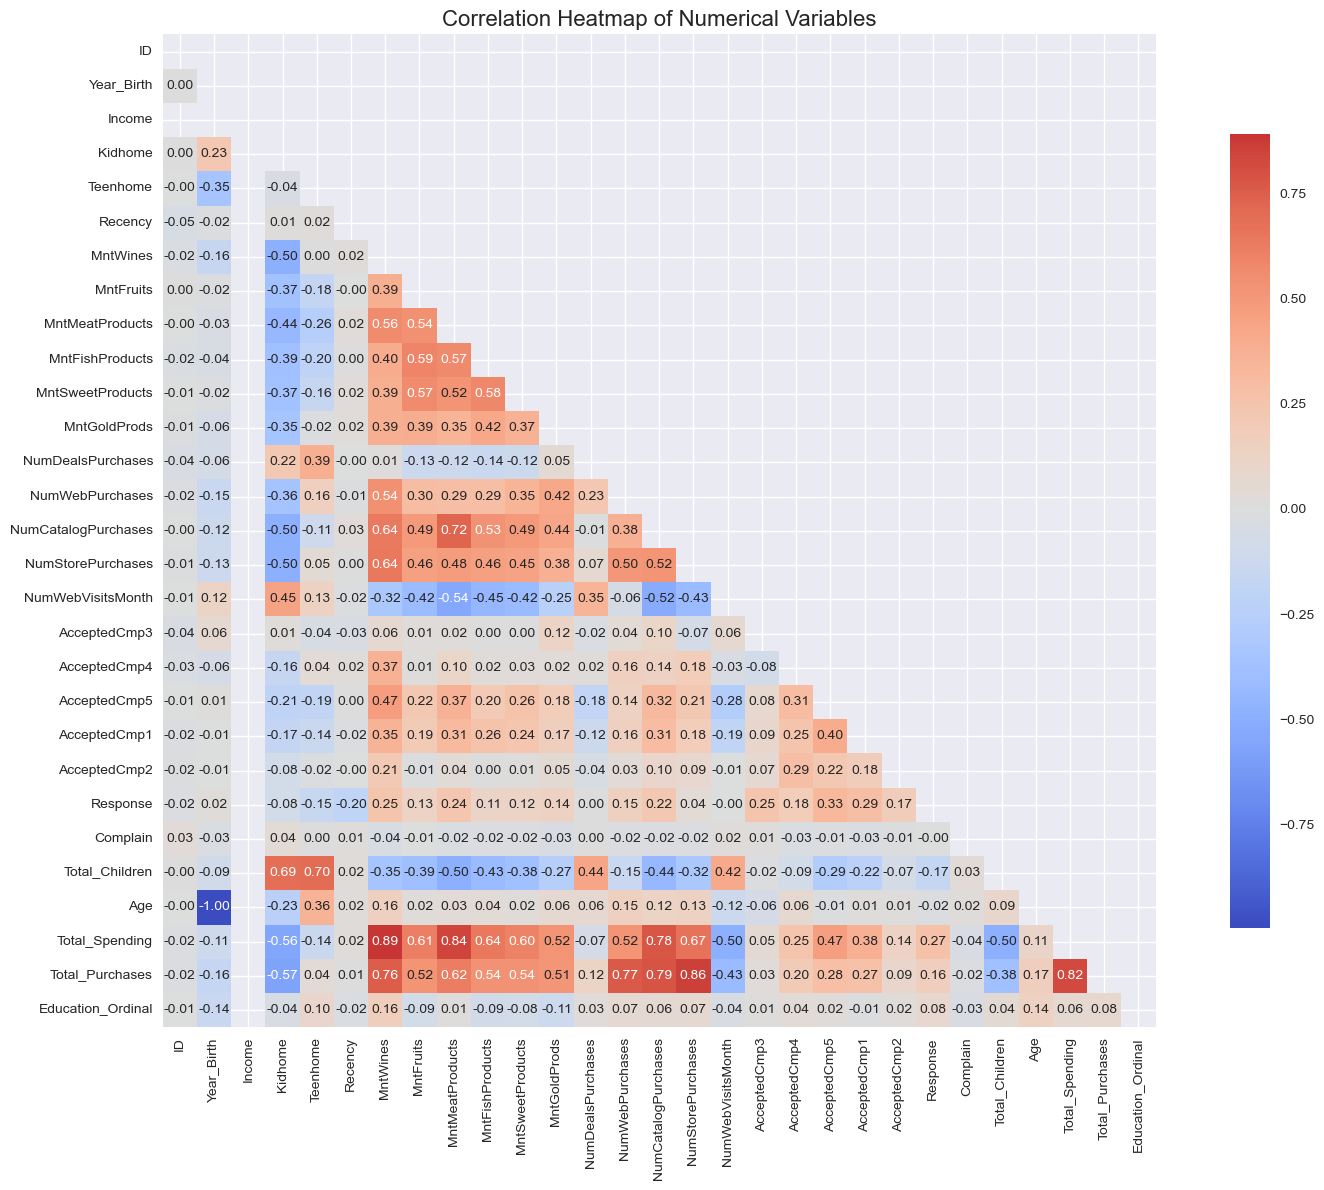


Top 10 strongest correlations:
MntWines             Total_Spending         0.891845
Total_Spending       MntWines               0.891845
NumStorePurchases    Total_Purchases        0.855454
Total_Purchases      NumStorePurchases      0.855454
Total_Spending       MntMeatProducts        0.842949
MntMeatProducts      Total_Spending         0.842949
Total_Spending       Total_Purchases        0.820734
Total_Purchases      Total_Spending         0.820734
                     NumCatalogPurchases    0.785609
NumCatalogPurchases  Total_Purchases        0.785609
dtype: float64


In [31]:
# 9. Correlation Analysis
# Select numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns for correlation: {len(numerical_cols)}")

if len(numerical_cols) > 1:
    # Calculate correlation matrix
    corr_matrix = df[numerical_cols].corr()
    
    # Create heatmap
    plt.figure(figsize=(16, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', 
                center=0, fmt='.2f', square=True, cbar_kws={"shrink": .8})
    plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Show strongest correlations
    corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
    corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlations
    print("\nTop 10 strongest correlations:")
    print(corr_pairs.head(10))
else:
    print("Not enough numerical columns for correlation analysis")

=== HYPOTHESIS TESTING ===


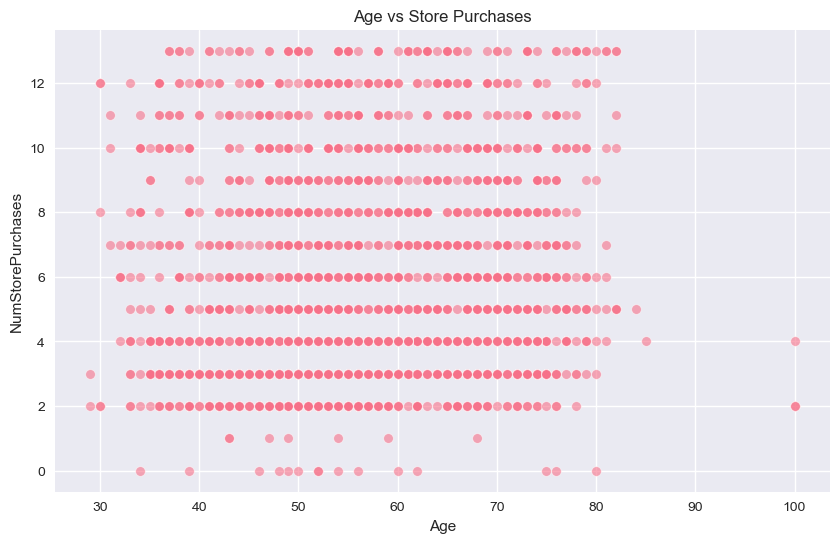

Age vs Store Purchases: r=0.133, p=0.000
Hypothesis 1: Supported


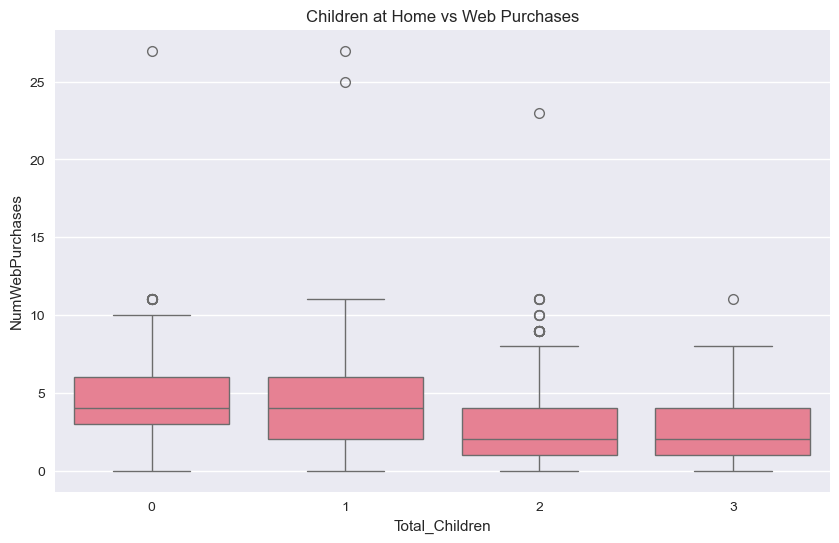

Children vs Web Purchases: r=-0.146, p=0.000
Hypothesis 2: Not supported


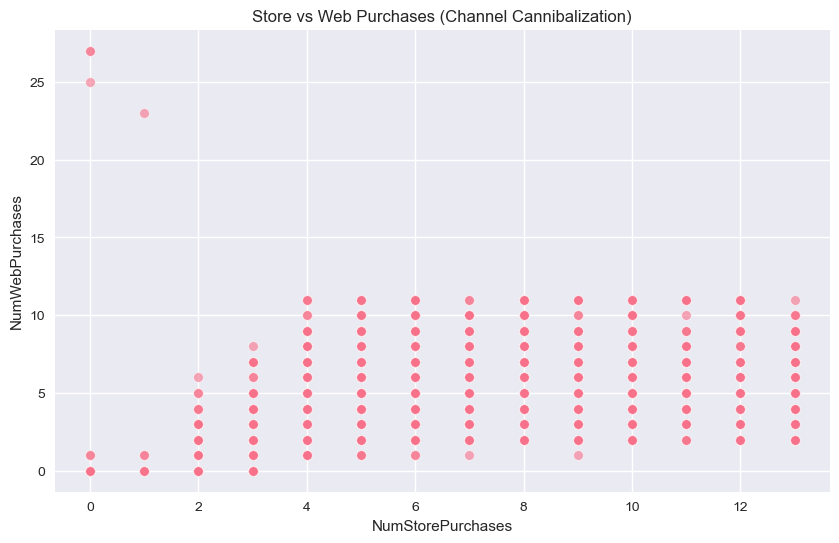

Store vs Web Purchases: r=0.503, p=0.000
Hypothesis 3: No significant cannibalization


In [32]:
# 10. Hypothesis Testing
print("=== HYPOTHESIS TESTING ===")

# Helper function for safe statistical tests
def safe_correlation(x, y):
    try:
        # Remove NaN values
        mask = ~(pd.isna(x) | pd.isna(y))
        if mask.sum() < 3:  # Need at least 3 points
            return None, None
        return stats.pearsonr(x[mask], y[mask])
    except:
        return None, None

# Hypothesis 1: Older people prefer shopping in-store
if all(col in df.columns for col in ['Age', 'NumStorePurchases']):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Age', y='NumStorePurchases', alpha=0.6)
    plt.title('Age vs Store Purchases')
    plt.show()
    
    corr, p_val = safe_correlation(df['Age'], df['NumStorePurchases'])
    if corr is not None:
        print(f"Age vs Store Purchases: r={corr:.3f}, p={p_val:.3f}")
        print(f"Hypothesis 1: {'Supported' if corr > 0 and p_val < 0.05 else 'Not supported'}")

# Hypothesis 2: Customers with kids prefer online shopping
if all(col in df.columns for col in ['Total_Children', 'NumWebPurchases']):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Total_Children', y='NumWebPurchases')
    plt.title('Children at Home vs Web Purchases')
    plt.show()
    
    corr, p_val = safe_correlation(df['Total_Children'], df['NumWebPurchases'])
    if corr is not None:
        print(f"Children vs Web Purchases: r={corr:.3f}, p={p_val:.3f}")
        print(f"Hypothesis 2: {'Supported' if corr > 0 and p_val < 0.05 else 'Not supported'}")

# Hypothesis 3: Channel cannibalization
if all(col in df.columns for col in ['NumStorePurchases', 'NumWebPurchases']):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='NumStorePurchases', y='NumWebPurchases', alpha=0.6)
    plt.title('Store vs Web Purchases (Channel Cannibalization)')
    plt.show()
    
    corr, p_val = safe_correlation(df['NumStorePurchases'], df['NumWebPurchases'])
    if corr is not None:
        print(f"Store vs Web Purchases: r={corr:.3f}, p={p_val:.3f}")
        print(f"Hypothesis 3: {'Cannibalization exists' if corr < 0 and p_val < 0.05 else 'No significant cannibalization'}")

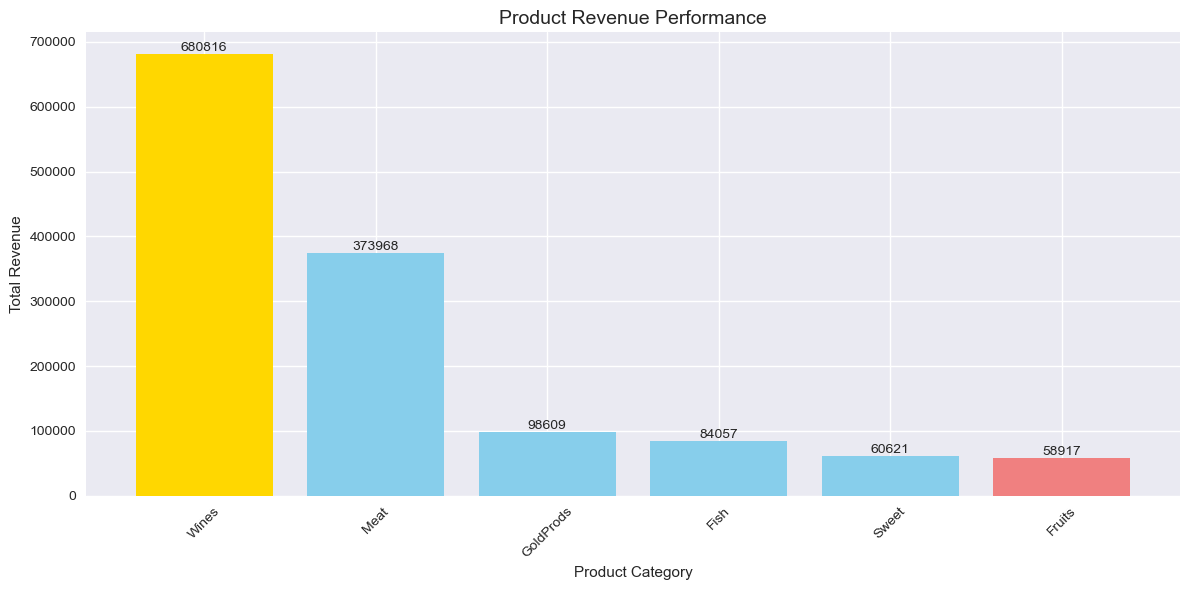

Best performing product: MntWines (Revenue: 680816)
Least performing product: MntFruits (Revenue: 58917)


In [33]:
# 11. Product Performance Analysis
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
available_products = [col for col in product_cols if col in df.columns]

if available_products:
    # Calculate total revenue per product
    product_revenue = df[available_products].sum().sort_values(ascending=False)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(product_revenue)), product_revenue.values, 
                   color=['gold' if i == 0 else 'lightcoral' if i == len(product_revenue)-1 else 'skyblue' 
                          for i in range(len(product_revenue))])
    plt.xticks(range(len(product_revenue)), 
               [col.replace('Mnt', '').replace('Products', '') for col in product_revenue.index], 
               rotation=45)
    plt.title('Product Revenue Performance', fontsize=14)
    plt.ylabel('Total Revenue')
    plt.xlabel('Product Category')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Best performing product: {product_revenue.index[0]} (Revenue: {product_revenue.iloc[0]:.0f})")
    print(f"Least performing product: {product_revenue.index[-1]} (Revenue: {product_revenue.iloc[-1]:.0f})")
else:
    print("Product columns not found in dataset")

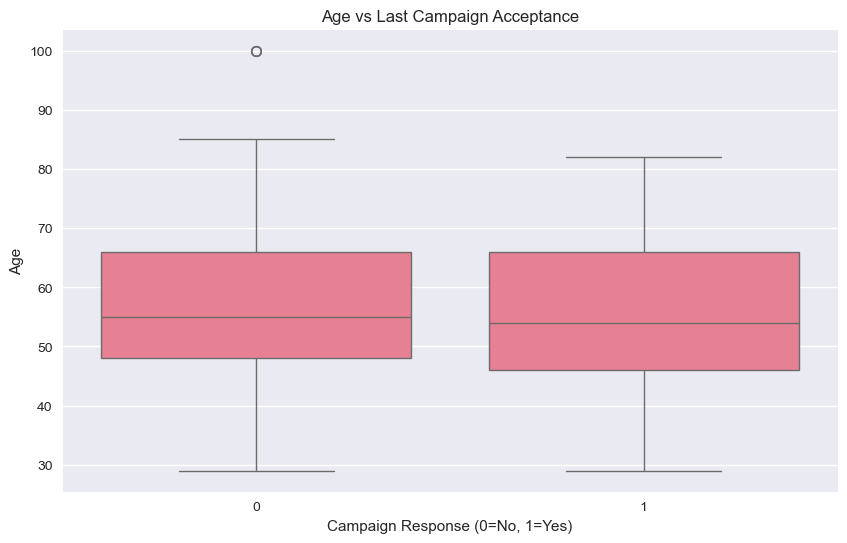

Age statistics by campaign response:
               mean        std  count
Response                             
0         56.257608  11.697062   1906
1         55.583832  12.398192    334


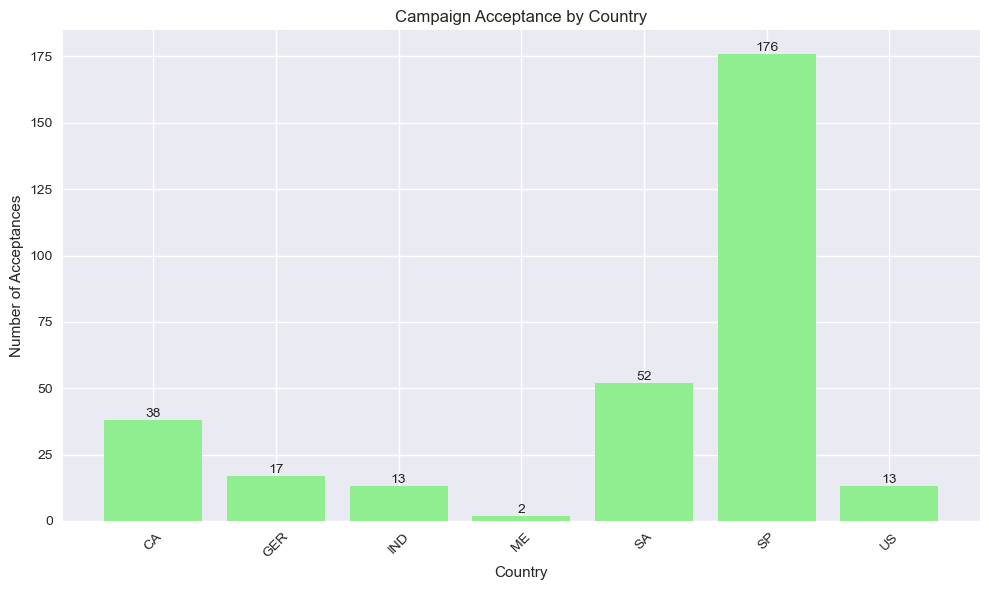

Country with most campaign acceptances: SP (176 acceptances)


In [34]:
# 12. Campaign Analysis
# Age vs Last Campaign Acceptance
campaign_col = 'Response'  # Assuming this is the last campaign response
if campaign_col in df.columns and 'Age' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=campaign_col, y='Age')
    plt.title('Age vs Last Campaign Acceptance')
    plt.xlabel('Campaign Response (0=No, 1=Yes)')
    plt.show()
    
    # Statistical summary
    campaign_age_stats = df.groupby(campaign_col)['Age'].agg(['mean', 'std', 'count'])
    print("Age statistics by campaign response:")
    print(campaign_age_stats)

# Country-wise campaign acceptance
country_cols = [col for col in df.columns if col.startswith('Country_')]
if campaign_col in df.columns and country_cols:
    # Find country with most acceptances
    country_acceptance = {}
    for country_col in country_cols:
        country_name = country_col.replace('Country_', '')
        acceptances = df[(df[country_col] == 1) & (df[campaign_col] == 1)].shape[0]
        country_acceptance[country_name] = acceptances
    
    if country_acceptance:
        # Visualization
        plt.figure(figsize=(10, 6))
        countries = list(country_acceptance.keys())
        acceptances = list(country_acceptance.values())
        
        bars = plt.bar(countries, acceptances, color='lightgreen')
        plt.title('Campaign Acceptance by Country')
        plt.ylabel('Number of Acceptances')
        plt.xlabel('Country')
        plt.xticks(rotation=45)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        best_country = max(country_acceptance, key=country_acceptance.get)
        print(f"Country with most campaign acceptances: {best_country} ({country_acceptance[best_country]} acceptances)")

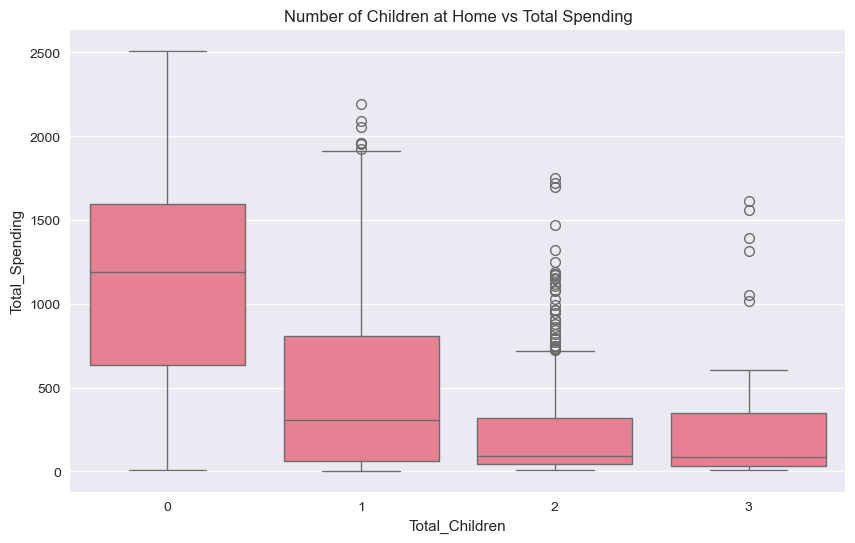

Spending statistics by number of children:
                       mean         std  count
Total_Children                                
0               1105.963754  644.856688    638
1                472.733156  478.000609   1128
2                245.947743  311.328287    421
3                274.603774  414.277051     53

Correlation between children and spending: r=-0.499, p=0.000


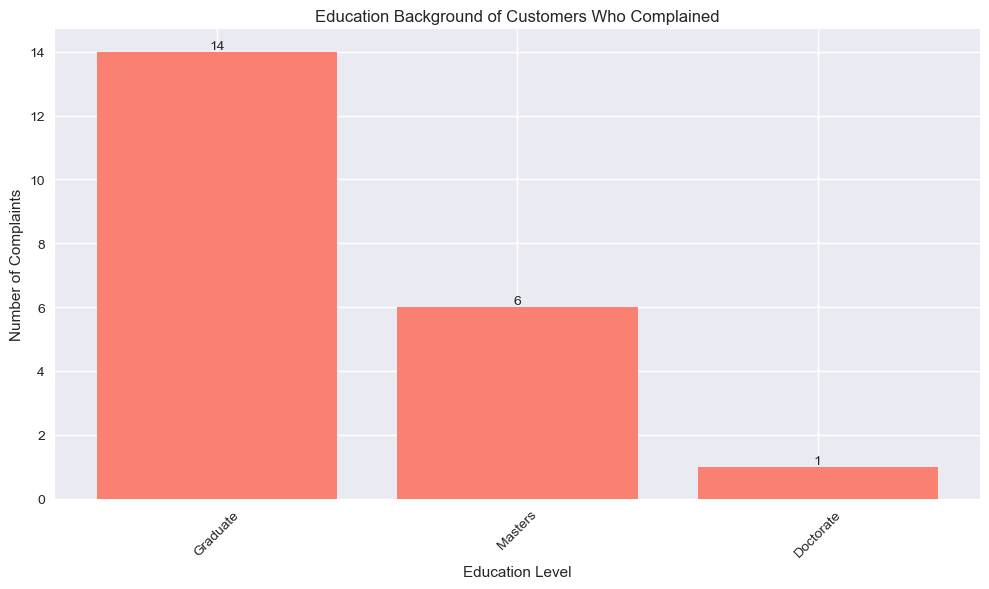

Complaints by education level:
Education
Graduate     14
Masters       6
Doctorate     1
Name: count, dtype: int64


In [35]:
# 13. Children vs Spending Analysis
if all(col in df.columns for col in ['Total_Children', 'Total_Spending']):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Total_Children', y='Total_Spending')
    plt.title('Number of Children at Home vs Total Spending')
    plt.show()
    
    # Statistical summary
    spending_by_children = df.groupby('Total_Children')['Total_Spending'].agg(['mean', 'std', 'count'])
    print("Spending statistics by number of children:")
    print(spending_by_children)
    
    # Correlation
    corr, p_val = safe_correlation(df['Total_Children'], df['Total_Spending'])
    if corr is not None:
        print(f"\nCorrelation between children and spending: r={corr:.3f}, p={p_val:.3f}")

# 14. Complaint Analysis by Education
complaint_col = 'Complain'
if complaint_col in df.columns and 'Education' in df.columns:
    # Education background of complainers
    complainers_education = df[df[complaint_col] == 1]['Education'].value_counts()
    
    if not complainers_education.empty:
        plt.figure(figsize=(10, 6))
        bars = plt.bar(complainers_education.index, complainers_education.values, color='salmon')
        plt.title('Education Background of Customers Who Complained')
        plt.ylabel('Number of Complaints')
        plt.xlabel('Education Level')
        plt.xticks(rotation=45)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        print("Complaints by education level:")
        print(complainers_education)
    else:
        print("No complaints found in the dataset")
else:
    print("Complaint or Education column not found")

In [36]:
# 15. Summary and Key Insights
print("=== MARKETING CAMPAIGN ANALYSIS SUMMARY ===")
print(f"Dataset size: {df.shape[0]} customers, {df.shape[1]} features")

# Key statistics
if 'Age' in df.columns:
    print(f"Age range: {df['Age'].min():.0f} - {df['Age'].max():.0f} years")
if 'Income' in df.columns:
    print(f"Income range: ${df['Income'].min():.0f} - ${df['Income'].max():.0f}")
if 'Total_Spending' in df.columns:
    print(f"Average total spending: ${df['Total_Spending'].mean():.2f}")
if 'Total_Children' in df.columns:
    print(f"Average children per household: {df['Total_Children'].mean():.2f}")

# Campaign performance
if 'Response' in df.columns:
    acceptance_rate = df['Response'].mean() * 100
    print(f"Campaign acceptance rate: {acceptance_rate:.1f}%")

print("\n=== ANALYSIS COMPLETE ===")
print("All visualizations and statistical tests have been performed.")
print("Review the outputs above for detailed insights into customer behavior and marketing effectiveness.")

=== MARKETING CAMPAIGN ANALYSIS SUMMARY ===
Dataset size: 2240 customers, 40 features
Age range: 29 - 100 years
Income range: $nan - $nan
Average total spending: $605.78
Average children per household: 0.95
Campaign acceptance rate: 14.9%

=== ANALYSIS COMPLETE ===
All visualizations and statistical tests have been performed.
Review the outputs above for detailed insights into customer behavior and marketing effectiveness.
